The first exercise of this homework contains small unrelated questions on code. The final exam may contain similar questions, in which you will be asked to analyze or correct a piece of code. 

The second exercise uses a physics dataset on which we perform linear classification.

In [1]:
# don't forget to run this command before running the script!

import pandas as pd
import numpy as np
np.random.seed(0)

import sklearn.model_selection as ms
import sklearn.linear_model as lm
import sklearn.preprocessing as pp
import matplotlib.pyplot as plt

## Exercise 1 (6 pt)

In [2]:
def loss(x, y, w, l):
    # x is a n \times d matrix, y is a vector
    return np.sum((y - x.dot(w))**2 / 2) + (l / 2) * np.sum(np.abs(w))

**Question 1 (1 pt)** What loss, seen in class, is computed by the function `loss` ? Explain in what contexts it is used, compared to other losses.

_Answer_ : ...

In [3]:
def ridge_estimator(x, y, l):
    n, d = x.shape
    return (x.T @ x + l * np.eye(d)) @ x.T @ y

**Question 2 (1 pt)** We want the function `ridge_estimator` defined above to compute the estimator that minimizes the Ridge loss. Is there any mistake in this code ? If yes, fix it.

_Answer_ : ...

In [4]:
def gradient_descent(x, y, B):
    """
    arguments:
        x -- n x d matrix
        y -- n vector
        B -- integer
    """
    # compute an estimator using gradient descent
    n, d = x.shape
    w = np.zeros(d)
    tolerance = 1e-3
    diff = np.inf

    eta = 0.1
    
    while diff > tolerance:
        w_old = np.copy(w)

        indices = np.random.choice(n, B)
        x_batch = x[indices]
        y_batch = y[indices]
        
        w -= eta * np.dot(x_batch.T, np.dot(x_batch, w) - y_batch)

        diff = np.sum((w_old - w)**2) / d
    return w

**Question 3 (2 pt)** The goal of the function `gradient_descent` is to compute an estimator using stochastic gradient descent.

a) What is the value of the regularization here ? 

_Answer_ : ...

b) Explain the role of the variable `eta`. 

_Answer_ : ...

c) What line(s) would you change (and how) to perform gradient descent instead of stochastic gradient descent ?

_Answer_ : ...

**Question 4 (2 pt)** In the function `gradient_logistic_l2`, implement the gradient of the following loss (as before, we use here labels equal to $\pm 1$) :
$$
    \mathcal{L}(\vec{w}) = \frac{1}{n} \left( \sum_{i = 1}^n \log \left( 1 + e^{- y_i \times \vec{w}^{\top} \vec{x}_i} \right) + \frac{\lambda}{2} \| \vec{w} \|^2 \right)
$$


In [5]:
def gradient_logistic_l2(w, X, y, l):
    # your code here 

## Exercise 2 (10 pt)

In this exercise, we will perform linear classification on the SUSY dataset. Here, each data sample corresponds to particle collision event, which will be either from background noise (label `0`) or a supersymmetric event (label `1`). The input is made of $18$ numerical features related to the collision.

Because the original dataset is quite large (more than 1 GB), we will work with a small version of it containing 10000 training samples, that you can download on the Moodle page, called `susy_small.csv`.

### Data preparation

First, we will clean the data to make it more convenient to work with.

In [1]:
def load_dataset():
    df = pd.read_csv('susy_small.csv')
    # TODO your code here 
    x = ...
    y = ...
    return x, y

**Question 1 (1 pt)** a) Implement the function `load_dataset` to return two numpy arrays `x` and `y`. `y` must contain the values in the column `SUSY` of the dataframe `df`, while `x` contains the rest of the data.

b) Observe the values taken by the labels $y$. Transform them such that they are either $-1$ or $1$ to be coherent with the notation seen in class.

In [12]:
def label_to_pm_one(y):
    y_new = # your code here
    return y_new

**Question 2 (1 pt)** As good practice, it is preferable to have normalized data that is to say that the mean of the input matrix `X` accross its first first dimension should be $0$, and its variance should be $1$. This is not the case here. We then want to write a function that does two things : 1) split the data into training and validation sets and 2) normalize the training data. 

Here are two possible functions, `function1` and `function2` written for this purpose. Which of them is preferrable to the other and why ? 

_Reminder_ : The function `sklearn.model_selection.train_test_split` splits a given dataset `X`, `y` into a training and test data. The role of  the argument `random_state=0` is for reproducibility purposes.

_Answer_ : ...

In [8]:
def function1(x, y):
    # First split into training and validation, then compute the mean and variance of training data to normalize
    x_train, x_test, y_train, y_test = ms.train_test_split(x, y, test_size=0.2, random_state=0)
    mean_x_train = np.mean(x_train, axis = 0)
    var_x_train  = np.var(x_train, axis = 0)
    x_train = (x_train - mean_x_train) / np.sqrt(var_x_train)
    x_test  = (x_test  - mean_x_train) / np.sqrt(var_x_train)
    return x_train, x_test, y_train, y_test

def function2(x, y):
    # First compute the mean and variance of data, then split into training and validation
    mean_x = np.mean(x, axis = 0)
    var_x  = np.var(x, axis = 0)
    x_train, x_test, y_train, y_test = ms.train_test_split(x, y, test_size=0.2, random_state=0)
    x_train = (x_train - mean_x) / np.sqrt(var_x)
    x_test  = (x_test  - mean_x) / np.sqrt(var_x)
    return x_train, x_test, y_train, y_test

# function_normalize = function1
# function_normalize = function2

### Logistic regression

**Question 4 (4 pt)** We want to run two methods to clasify the data : logistic regression with $\ell_1$ and $\ell_2$ penalty. 

a) First, implement the functions `logistic_l2` and `logistic_l1` that compute and returns the estimator for their corresponding losses. To this end, use the `sklearn.linear_model.LogisticRegression` class with the appropriate choice of penalty.

_Important note_ : in the initialization of `LogisticRegression`, set the argument `solver='liblinear'` to avoid an error.

In [9]:
def logistic_l1(x, y, l):
    # your code here

def logistic_l2(x, y, l):
    # your code here

b) Implement the functions `logistic_l2_crossvalidation` and `logistic_l1_crossvalidation` that compute the accuracy on the _validation data_ of the estimators trained for different values of $\lambda$ : for a list `lambda_range` that contains a list of the $\lambda$ to be tested, the function should return another list of the same length that contains the accuracy for each $\lambda$.

In [10]:
def logistic_l2_crossvalidation(x_train, y_train, x_val, y_val, lambda_range):
    # your code here

def logistic_l1_crossvalidation(x_train, y_train, x_val, y_val, lambda_range):
    # your code here

c) Using the functions of the previous questions, plot the validation accuracy for `lambda_range = np.logspace(-2, 5, 50)` for both $\ell_1$ and $\ell_2$ regularizations (don't hesitate to use a logarithmic scale for the x-axis). What are the optimal values $\lambda_1, \lambda_2$ ? 

_Answer_ : ...

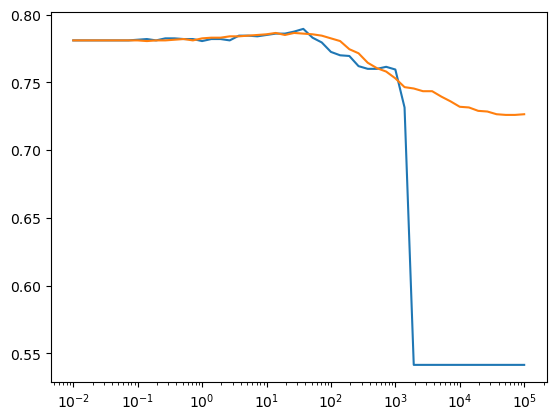

In [14]:
# 1) load the data and normalize it 

# 2) compute the scores for logistic regression with l1 penalty

# 3) compute the scores for logistic regression with l2 penalty

# 4) plot the scores as a function of lambda_range

#uncomment to visualize the results
# plt.xscale('log')
# plt.ylabel("Scores")
# plt.xlabel("Lambda")
# plt.legend()
# plt.show()

# 5) print the best lambda for l1 and l2 penalties

d) When $\lambda$ is big enough, the validation accuracy for $\ell_1$ regularization becomes constant to some value (let's call it $acc_{\infty}$). Justify that $acc_{\infty}$ is equal to the proportion of background events (i.e samples with label $-1$) in the validation data.

_Answer_ : 

### Adding interacting polynomial features

In this section, we will try to improve our classifier by adding features in our data, namely the product of the 18 existing features. That is to say, for all pair of indices $0 \leqslant i, j \leqslant 17$ with $i \neq j$ we will add the feature `X[:, i] * X[:, j]` to the matrix `X` (to have 171 features in total).

**Question 5 (1 pt)** Implement the function `add_interactions` to add the features described above.

_Hint_ : You can use a class seen in the exercise session to do so, with the correct arguments `degree` and `interaction_only`. The final dimension should be 171.


In [16]:
def add_interactions(X):
    # youre code here

**Question 6 (3 pt)** Redo the steps of question 3 and 4 to find the optimal regularization strength $\lambda_{1, poly}$ and $\lambda_{2, poly}$ that correspond to the best validation accuracy. Did the validation accuracy improve compared to question 4 ? 

_NOTE_ : The computation may take some time, so be patient.

_Answer_ : ...

In [1]:
# your code here 
